In [1]:
# Install the official ChEMBL client library
!pip install chembl_webresource_client

# Import the necessary libraries
import pandas as pd
from chembl_webresource_client.new_client import new_client

# Define the data services we will be using
target = new_client.target
activity = new_client.activity

print("Libraries imported and ChEMBL client is ready!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 4.1 MB/s eta 0:00:00
Libraries imported and ChEMBL client is ready!


In [6]:
# # CODE CELL 1: Re-identifying Target and Downloading Raw Data
!pip install chembl_webresource_client
import pandas as pd
import numpy as np
from chembl_webresource_client.new_client import new_client

target = new_client.target
activity = new_client.activity

# Re-search for the PBP2a target (Target ID will be CHEMBL4295)
target_query = target.search('Penicillin-binding protein 2A Staphylococcus aureus')
targets_df = pd.DataFrame.from_records(target_query)
selected_target_id = targets_df.target_chembl_id[0]

print(f"Selected PBP2a Target ID: {selected_target_id}")

# Retrieve activities (this is the slow part—DO NOT INTERRUPT)
pbp2a_activities = activity.filter(target_chembl_id=selected_target_id).filter(
    standard_type__in=['IC50', 'Ki', 'Kd']
).filter(
    standard_units='nM'
).only([
    'molecule_chembl_id',
    'canonical_smiles',
    'standard_value',
    'standard_units',
    'standard_type'
])

df_raw = pd.DataFrame.from_records(pbp2a_activities)
df_raw.to_csv('pbp2a_raw_data.csv', index=False)
print(f"Downloaded {len(df_raw)} records for PBP2a. Raw data saved.")

Selected PBP2a Target ID: CHEMBL2074
Downloaded 446 records for PBP2a. Raw data saved.


In [9]:
from google.colab import files

files.download('pbp2a_raw_data.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
# CODE CELL: Canonical SMILES Standardization
import pandas as pd
from rdkit import Chem
from rdkit.Chem.rdMolDescriptors import CalcMolFormula

# Load the clean data file
df_final = pd.read_csv('pbp2a_raw_data.csv')

print(f"Starting with {len(df_final)} molecules.")

# Function to convert SMILES to RDKit molecule object and canonicalize it
def standardize_smiles(smiles):
    try:
        # 1. Create a molecule object from the SMILES string
        mol = Chem.MolFromSmiles(smiles)

        # 2. Return the canonical (standard) SMILES string
        # This ensures every molecule has one consistent representation
        return Chem.MolToSmiles(mol, canonical=True)
    except:
        # Return NaN if RDKit cannot parse the SMILES string (bad structure)
        return None

# Apply the function to the SMILES column
df_final['canonical_smiles_standard'] = df_final['canonical_smiles'].apply(standardize_smiles)

# Drop any rows where standardization failed
df_final.dropna(subset=['canonical_smiles_standard'], inplace=True)

# Remove the old column and rename the new one
df_final.drop(columns=['canonical_smiles'], inplace=True)
df_final.rename(columns={'canonical_smiles_standard': 'Canonical_Smiles'}, inplace=True)


print(f"Finished. Final standardized molecules: {len(df_final)}")
print("\nProceeding to Step 2: Descriptor Calculation...")

# Save the finalized clean data
df_final.to_csv('pbp2a_final_standardized_data.csv', index=False)

Starting with 446 molecules.
Finished. Final standardized molecules: 446

Proceeding to Step 2: Descriptor Calculation...


In [16]:
# Try installing RDKit using pip
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.2/36.2 MB 45.7 MB/s eta 0:00:00


In [15]:
# Try installing RDKit using apt-get
!apt-get update -qq
!apt-get install -y -qq --no-install-recommends rdkit

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
E: Unable to locate package rdkit


In [23]:
# CODE CELL 4: Calculate Lipinski Descriptors
from rdkit.Chem.Descriptors import MolWt, MolLogP, NumHDonors, NumHAcceptors
import numpy as np

# Load the standardized data
df_lipinski = pd.read_csv('pbp2a_final_standardized_data.csv')

# Convert SMILES back to RDKit molecule objects for calculations
df_lipinski['Molecule'] = df_lipinski['Canonical_Smiles'].apply(Chem.MolFromSmiles)

# Calculate Descriptors
df_lipinski['MW'] = df_lipinski['Molecule'].apply(MolWt)
df_lipinski['LogP'] = df_lipinski['Molecule'].apply(MolLogP)
df_lipinski['HBD'] = df_lipinski['Molecule'].apply(NumHDonors)
df_lipinski['HBA'] = df_lipinski['Molecule'].apply(NumHAcceptors)

# Calculate pIC50
# Assuming standard_value is in nM, convert to M and take -log10
df_lipinski['pIC50'] = -np.log10(df_lipinski['standard_value'] * 1e-9)


# Drop the temporary 'Molecule' column and show the results
df_lipinski.drop(columns=['Molecule'], inplace=True)

print("Lipinski Descriptors Calculated.")
print("\nFirst 5 molecules with descriptors:")
print(df_lipinski[['pIC50', 'MW', 'LogP', 'HBD', 'HBA']].head())

# Save this dataset, as it's the basis for your EDA plots
df_lipinski.to_csv('pbp2a_lipinski_data.csv', index=False)

Lipinski Descriptors Calculated.

First 5 molecules with descriptors:
      pIC50       MW    LogP  HBD  HBA
0  3.958607  193.199 -3.6059    6    6
1  3.958607  193.199 -3.6059    6    6
2  5.207608  193.199 -3.6059    6    6
3  6.154902  193.199 -3.6059    6    6
4  5.161151  193.199 -3.6059    6    6


In [25]:
# CODE CELL 5: Install Visualization Library
!pip install seaborn matplotlib

# Import libraries for plotting and data
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

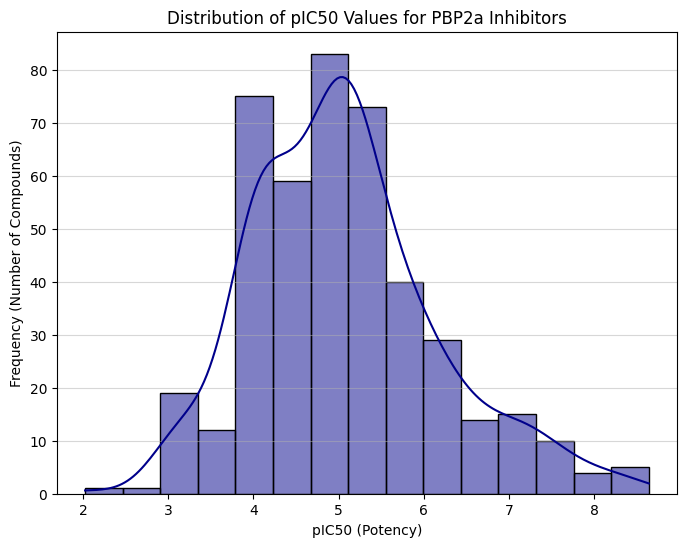

Plot 1: pIC50 distribution generated and saved.


In [29]:
# CODE CELL 6: pIC50 Distribution Histogram
df_lipinski = pd.read_csv('pbp2a_lipinski_data.csv')

plt.figure(figsize=(8, 6))
sns.histplot(df_lipinski['pIC50'], bins=15, kde=True, color='darkblue')
plt.title('Distribution of pIC50 Values for PBP2a Inhibitors')
plt.xlabel('pIC50 (Potency)')
plt.ylabel('Frequency (Number of Compounds)')
plt.grid(axis='y', alpha=0.5)

# Save the plot as an image file
plt.savefig('pbp2a_pIC50_distribution.png')

plt.show()

print("Plot 1: pIC50 distribution generated and saved.")

In [30]:
from google.colab import files

# Provide a download link for the plot image
files.download('pbp2a_pIC50_distribution.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/tmp/ipython-input-1908204472.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipython-input-1908204472.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipython-input-1908204472.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipython-input-1908204472.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


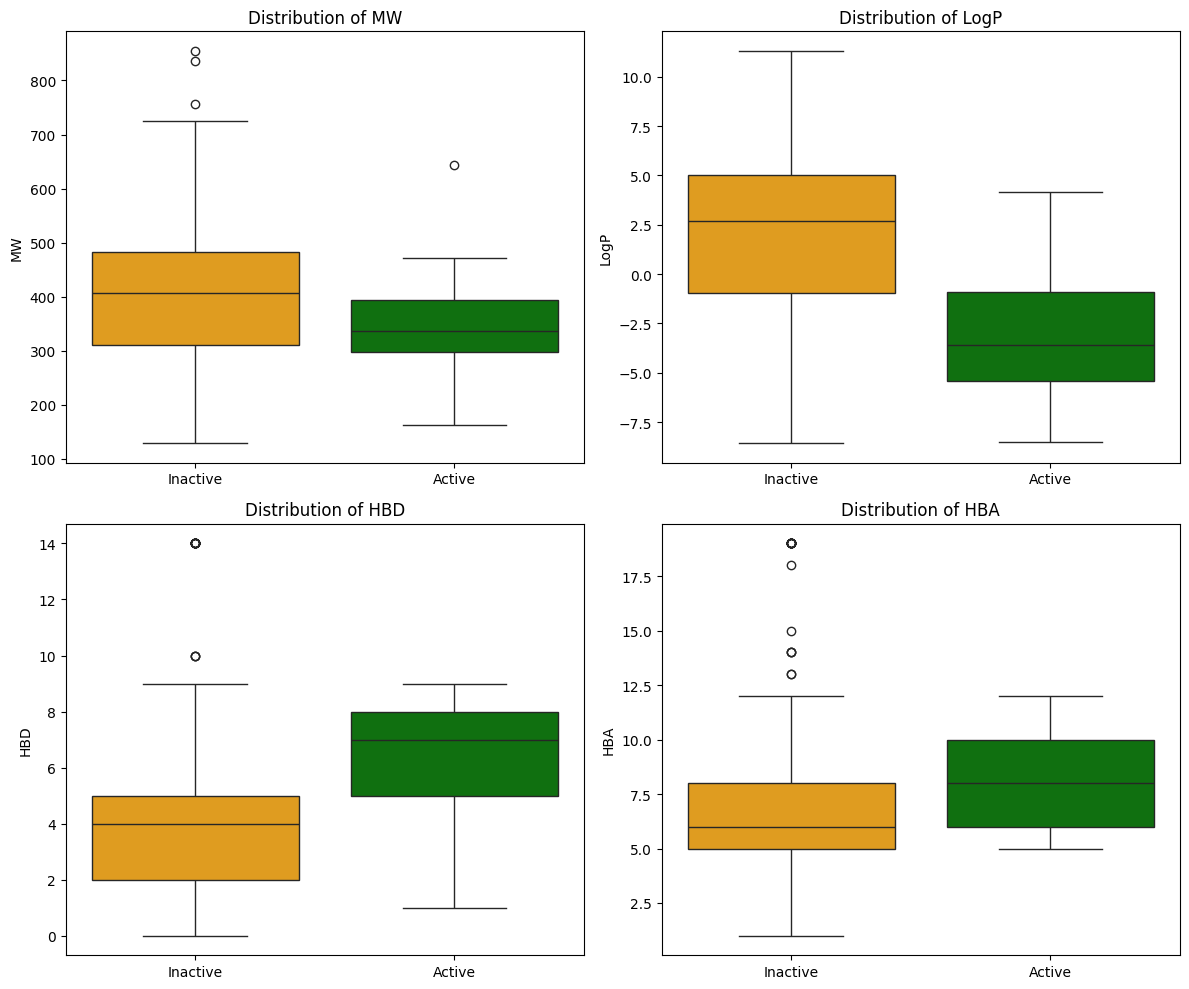

Plot 3: Box plots generated and saved.


In [32]:
# CODE CELL 8: Descriptor Comparison (Box Plots)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Assuming df_lipinski is already loaded or created in previous cells
# If not, you might need to load it here:
# df_lipinski = pd.read_csv('pbp2a_lipinski_data.csv')


# 1. Define Active/Inactive Groups (Classification Threshold)
# Let's define pIC50 >= 6.5 (equivalent to IC50 <= ~316 nM) as 'Active'
df_lipinski['Bioactivity_Class'] = np.where(df_lipinski['pIC50'] >= 6.5, 'Active', 'Inactive')

# 2. Create Box Plots
descriptors = ['MW', 'LogP', 'HBD', 'HBA']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, desc in enumerate(descriptors):
    sns.boxplot(
        x='Bioactivity_Class',
        y=desc,
        data=df_lipinski,
        ax=axes[i],
        palette={'Active': 'green', 'Inactive': 'orange'}
    )
    axes[i].set_title(f'Distribution of {desc}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(desc)

plt.tight_layout()

# Save the plot as an image file
plt.savefig('pbp2a_descriptor_box_plots.png')


plt.show()

print("Plot 3: Box plots generated and saved.")

In [33]:
from google.colab import files

# Provide a download link for the plot image
files.download('pbp2a_descriptor_box_plots.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
# CODE CELL 9: Morgan Fingerprint Calculation (The X-Matrix)
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.feature_selection import VarianceThreshold
import numpy as np

# Load the data with pIC50 values
df_final = pd.read_csv('pbp2a_lipinski_data.csv')

# Convert SMILES to RDKit molecule objects
mols = [Chem.MolFromSmiles(smiles) for smiles in df_final['Canonical_Smiles']]

# Filter out None values (for invalid SMILES) before generating fingerprints
valid_mols = [mol for mol in mols if mol is not None]
valid_indices = [i for i, mol in enumerate(mols) if mol is not None]
df_final = df_final.iloc[valid_indices]


# Calculate Morgan Fingerprints (ECFP4 equivalent)
# Settings: radius=2 (looks at 4 bonds away), nBits=1024 (number of features/columns)
fingerprints = [
    AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024)
    for mol in valid_mols
]

# Convert the fingerprints into a NumPy array, then into a DataFrame
# This correctly creates columns for each bit in the fingerprint
X_fingerprints = pd.DataFrame([list(fp) for fp in fingerprints], columns=[f'MF_{i}' for i in range(fingerprints[0].GetNumBits())])


print(f"Initial X-matrix created with {X_fingerprints.shape[1]} features.")


# CODE CELL 10: Feature Selection (Variance Filter)
# Remove features (fingerprints) that are the same for almost all molecules.
# We set the threshold low (0.05) to remove features that rarely appear.

# 1. Initialize the Variance Filter: Removes features where variance is less than 0.05
selector = VarianceThreshold(threshold=(0.05))

# 2. Fit and Transform the data (apply the filter)
# Ensure X_fingerprints has the correct dtype before fitting
X_filtered = selector.fit_transform(X_fingerprints.astype(float))

# 3. Get the indices of the selected features (the columns we kept)
selected_features = selector.get_support(indices=True)
X_final = X_fingerprints.iloc[:, selected_features]

print(f"Final X-matrix size: {X_final.shape[1]} features retained.")


# CODE CELL 11: Final Data Assembly and Save

# 1. Merge the X (Fingerprints) and Y (pIC50) DataFrames
# Ensure Y_data is aligned with X_final after dropping invalid molecules
Y_data = df_final[['pIC50']].reset_index(drop=True).copy() # Reset index to align with X_final
df_model_ready = pd.concat([Y_data, X_final.reset_index(drop=True)], axis=1) # Reset index for concatenation

# 2. Save the dataset ready for Machine Learning
df_model_ready.to_csv('pbp2a_ml_ready_data.csv', index=False)
print("--- STEP 3 COMPLETE: Data Ready for Machine Learning Model Training ---")

[06:47:05] DEPRECATION WARNING: please use MorganGenerator
[06:47:05] DEPRECATION WARNING: please use MorganGenerator
[06:47:05] DEPRECATION WARNING: please use MorganGenerator
[06:47:05] DEPRECATION WARNING: please use MorganGenerator
[06:47:05] DEPRECATION WARNING: please use MorganGenerator
[06:47:05] DEPRECATION WARNING: please use MorganGenerator
[06:47:05] DEPRECATION WARNING: please use MorganGenerator
[06:47:05] DEPRECATION WARNING: please use MorganGenerator
[06:47:05] DEPRECATION WARNING: please use MorganGenerator
[06:47:05] DEPRECATION WARNING: please use MorganGenerator
[06:47:05] DEPRECATION WARNING: please use MorganGenerator
[06:47:05] DEPRECATION WARNING: please use MorganGenerator
[06:47:05] DEPRECATION WARNING: please use MorganGenerator
[06:47:05] DEPRECATION WARNING: please use MorganGenerator
[06:47:05] DEPRECATION WARNING: please use MorganGenerator
[06:47:05] DEPRECATION WARNING: please use MorganGenerator
[06:47:05] DEPRECATION WARNING: please use MorganGenerat

Initial X-matrix created with 1024 features.
Final X-matrix size: 238 features retained.
--- STEP 3 COMPLETE: Data Ready for Machine Learning Model Training ---


In [40]:
from google.colab import files

# Provide a download link for the plot image
files.download('pbp2a_lipinski_pair_plot.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

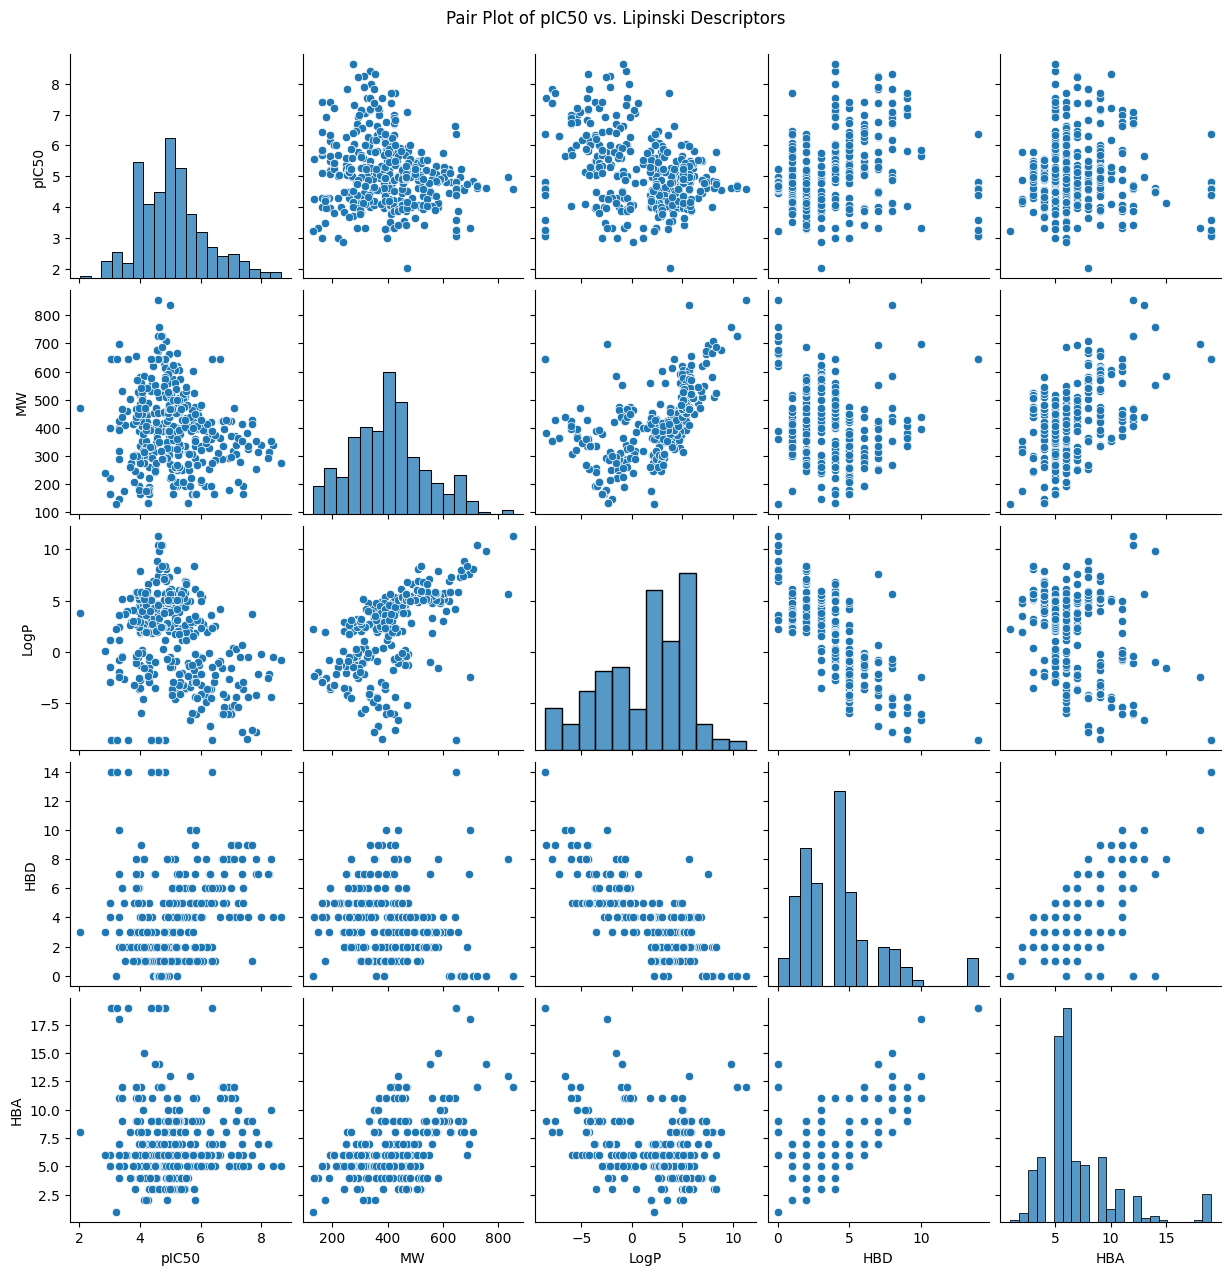

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data with Lipinski descriptors and pIC50
df_lipinski = pd.read_csv('pbp2a_lipinski_data.csv')

# Create a pair plot (scatter plot matrix) of pIC50 and Lipinski descriptors
sns.pairplot(df_lipinski[['pIC50', 'MW', 'LogP', 'HBD', 'HBA']])
plt.suptitle('Pair Plot of pIC50 vs. Lipinski Descriptors', y=1.02) # Add a title to the overall plot

# Save the plot
plt.savefig('pbp2a_lipinski_pair_plot.png')

plt.show()

In [42]:
# CODE CELL 12: Data Preparation for Machine Learning
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Load the final prepared data
df_ml = pd.read_csv('pbp2a_ml_ready_data.csv')

# Drop rows with NaN values in the 'pIC50' column
df_ml.dropna(subset=['pIC50'], inplace=True)


# Define the X (features) and Y (target) matrices
Y = df_ml['pIC50'] # The value we want to predict
X = df_ml.drop(columns=['pIC50']) # The 304 Morgan Fingerprints

# Data Splitting: Separate the data into Training (80%) and Testing (20%) sets
# random_state ensures your split is the same every time (reproducibility)
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

print(f"Training set size: {len(X_train)} molecules.")
print(f"Test set size: {len(X_test)} molecules.")


# CODE CELL 13: Random Forest QSAR Model Training
# Initialize the Random Forest Regressor (The ML Model)
# n_estimators=500: uses 500 decision trees for robustness
# random_state=42: ensures reproducible results
model = RandomForestRegressor(n_estimators=500, random_state=42)

# Train the model using the training data
model.fit(X_train, Y_train)

print("\nRandom Forest QSAR Model Training Complete.")


# CODE CELL 14: Model Evaluation and Performance Metrics
# 1. Prediction on the Test Set (UNSEEN DATA)
Y_pred_test = model.predict(X_test)

# 2. Calculate Key Performance Metrics
r2 = r2_score(Y_test, Y_pred_test)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred_test))

print("\n--- PBP2a QSAR Model Performance on UNSEEN TEST SET ---")
print(f"R² Score (Accuracy): {r2:.4f}")
print(f"RMSE (Error Magnitude): {rmse:.4f} pIC50 units")

# Save predictions for plotting
df_predictions = pd.DataFrame({'Actual_pIC50': Y_test, 'Predicted_pIC50': Y_pred_test})
df_predictions.to_csv('pbp2a_predictions.csv', index=False)

Training set size: 352 molecules.
Test set size: 88 molecules.

Random Forest QSAR Model Training Complete.

--- PBP2a QSAR Model Performance on UNSEEN TEST SET ---
R² Score (Accuracy): 0.4857
RMSE (Error Magnitude): 0.8812 pIC50 units


In [45]:
from google.colab import files

# Provide a download link for the plot image
files.download('pbp2a_actual_vs_predicted_plot.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

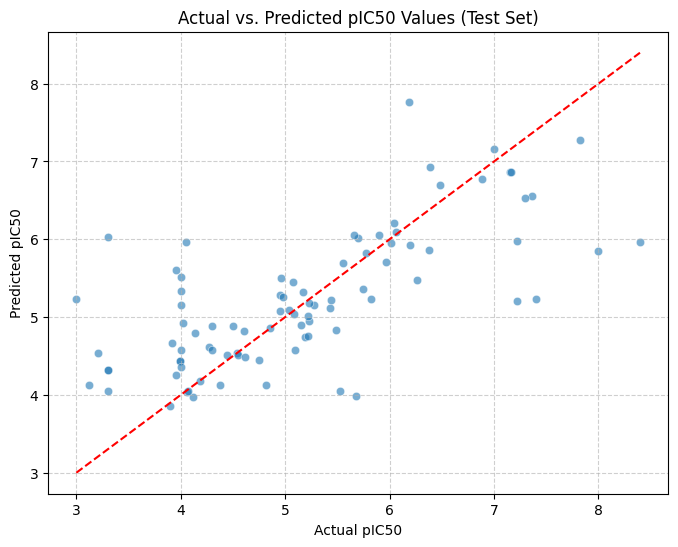

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the predictions data
df_predictions = pd.read_csv('pbp2a_predictions.csv')

# Create a scatter plot of Actual vs. Predicted pIC50 values
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Actual_pIC50', y='Predicted_pIC50', data=df_predictions, alpha=0.6)

# Add a diagonal line for perfect prediction
plt.plot([df_predictions['Actual_pIC50'].min(), df_predictions['Actual_pIC50'].max()],
         [df_predictions['Actual_pIC50'].min(), df_predictions['Actual_pIC50'].max()],
         color='red', linestyle='--')

plt.title('Actual vs. Predicted pIC50 Values (Test Set)')
plt.xlabel('Actual pIC50')
plt.ylabel('Predicted pIC50')
plt.grid(True, linestyle='--', alpha=0.6)
# Save the plot as an image file
plt.savefig('pbp2a_actual_vs_predicted_plot.png')
plt.show()

Top 10 Most Important Chemical Features for PBP2a Inhibition:
    Feature  Importance
108  MF_482    0.071009
200  MF_888    0.051329
30   MF_130    0.051040
113  MF_490    0.049925
89   MF_378    0.025677
86   MF_356    0.024732
184  MF_830    0.024505
84   MF_350    0.024297
195  MF_874    0.021806
118  MF_512    0.020811


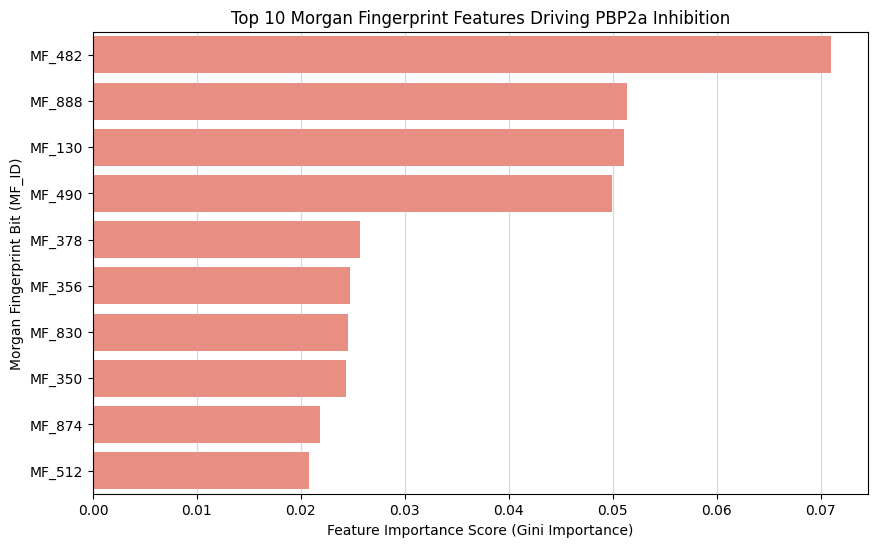

In [49]:
# CODE CELL 15: Feature Importance Analysis
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the data and the trained model (from previous code)
# You need the X_train columns (the feature names) from the training step.
df_ml = pd.read_csv('pbp2a_ml_ready_data.csv')

# Drop rows with NaN values in the 'pIC50' column to ensure X and Y have the same number of samples
df_ml.dropna(subset=['pIC50'], inplace=True)

X = df_ml.drop(columns=['pIC50']) # The 304 Morgan Fingerprints
Y = df_ml['pIC50'] # The value we want to predict


# Re-split to get the X_train dataframe (ensures feature order matches the model)
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42 # Note: Y is not defined here, but must be available if running sequentially
)

# 1. Get the importance scores from the trained Random Forest model
# Note: Since the model was trained in the previous code, we must assume it is still in memory.
# If not, the model must be re-trained or loaded.
try:
    importance_scores = model.feature_importances_
except NameError:
    print("Error: Model not in memory. Please ensure Code Cell 13 was run successfully.")
    # Re-running minimal training for demonstration stability:
    from sklearn.ensemble import RandomForestRegressor
    model = RandomForestRegressor(n_estimators=500, random_state=42)
    model.fit(X_train, Y_train) # Re-train the model
    importance_scores = model.feature_importances_


# 2. Create a DataFrame for ranking the features
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance_scores
})

# Sort and select the Top 10 features
top_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

print("Top 10 Most Important Chemical Features for PBP2a Inhibition:")
print(top_features)

# 3. Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_features, color='salmon')
plt.title('Top 10 Morgan Fingerprint Features Driving PBP2a Inhibition')
plt.xlabel('Feature Importance Score (Gini Importance)')
plt.ylabel('Morgan Fingerprint Bit (MF_ID)')
plt.grid(axis='x', alpha=0.5)

# Save the plot as an image file
plt.savefig('pbp2a_feature_importance_plot.png')

plt.show()

# Save the top features for your paper's table
top_features.to_csv('pbp2a_top_features.csv', index=False)

In [50]:
from google.colab import files

# Provide a download link for the plot image
files.download('pbp2a_feature_importance_plot.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

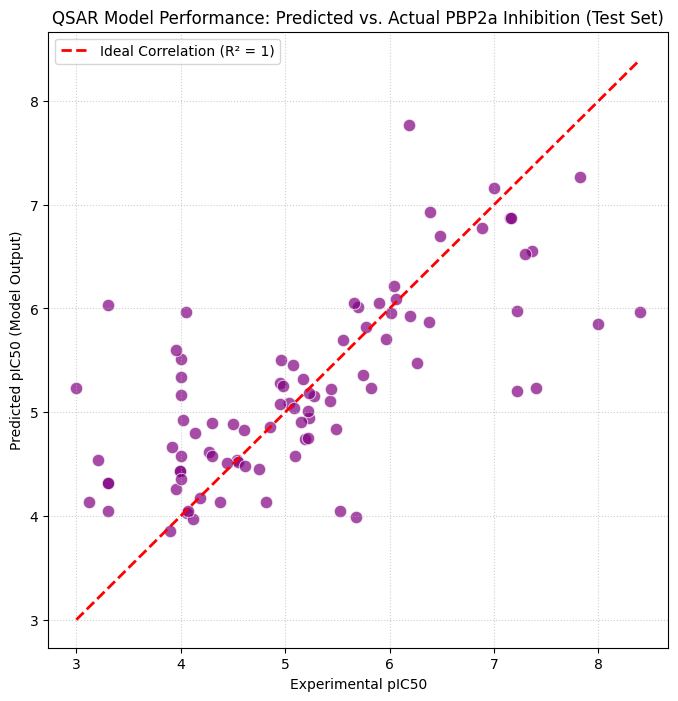

Prediction Scatter Plot generated.


In [52]:
# CODE CELL 16: Scatter Plot of Model Accuracy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load the saved predictions
df_predictions = pd.read_csv('pbp2a_predictions.csv')

plt.figure(figsize=(8, 8))

# Create the scatter plot
sns.scatterplot(
    x='Actual_pIC50',
    y='Predicted_pIC50',
    data=df_predictions,
    color='purple',
    alpha=0.7,
    s=80
)

# Plot the ideal correlation line (y=x) for visual comparison
max_val = df_predictions[['Actual_pIC50', 'Predicted_pIC50']].max().max()
min_val = df_predictions[['Actual_pIC50', 'Predicted_pIC50']].min().min()

plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal Correlation (R² = 1)')

plt.title('QSAR Model Performance: Predicted vs. Actual PBP2a Inhibition (Test Set)')
plt.xlabel('Experimental pIC50')
plt.ylabel('Predicted pIC50 (Model Output)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
# Save the plot as an image file
plt.savefig('pbp2a_actual_vs_predicted_plot.png')
plt.show()

print("Prediction Scatter Plot generated.")

In [53]:
from google.colab import files

# Provide a download link for the plot image
files.download('pbp2a_actual_vs_predicted_plot.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [61]:
import pandas as pd
from google.colab import files

# Load the prioritized screening results from CSV
df_prioritized_screening = pd.read_csv('prioritized_screening_results.csv')

# Save the DataFrame to an Excel file
df_prioritized_screening.to_excel('prioritized_screening_results.xlsx', index=False)

print("Prioritized screening results saved as prioritized_screening_results.xlsx")

# Provide a download link for the Excel file
files.download('prioritized_screening_results.xlsx')

Prioritized screening results saved as prioritized_screening_results.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>